# Figure 2 — bicubic vs bilinear upsampling (96→224)

Loads one **preprocessed Macenko** PCam patch, upsamples with bilinear and bicubic (same modes as Virchow2 training), and saves a publication figure.

**Output:** `reports/figures/figure2_bicubic_vs_bilinear.png` and `.pdf`

In [17]:
from __future__ import annotations

from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

_cwd = Path.cwd().resolve()
REPO = _cwd if (_cwd / "pcam_data").is_dir() else _cwd.parent
if not (REPO / "pcam_data").is_dir():
    REPO = Path(r"C:\GP_ECG")

PREPROC_DIR = REPO / "pcam_data" / "preprocessed_macenko_benchmark_style"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PREP_IDX = 36793
# 43670

SPLIT = "train"  # train | valid | test — train holds index 43679
TARGET_SIZE = 224
DPI = 300

SPLIT_FILES = {
    "train": PREPROC_DIR / "train_x.h5",
    "valid": PREPROC_DIR / "valid_x.h5",
    "test": PREPROC_DIR / "test_x.h5",
}

FIG_PNG = FIG_DIR / "figure2_bicubic_vs_bilinear.png"
FIG_PDF = FIG_DIR / "figure2_bicubic_vs_bilinear.pdf"

print("REPO:", REPO)
print("H5:", SPLIT_FILES[SPLIT])

REPO: C:\GP_ECG
H5: C:\GP_ECG\pcam_data\preprocessed_macenko_benchmark_style\train_x.h5


In [18]:
def load_preprocessed_patch(split: str, prep_idx: int) -> np.ndarray:
    path = SPLIT_FILES[split]
    if not path.is_file():
        raise FileNotFoundError(path)
    with h5py.File(path, "r") as f:
        n = f["x"].shape[0]
        if not (0 <= prep_idx < n):
            raise IndexError(f"prep_idx={prep_idx} out of range for {split} (n={n})")
        x = np.array(f["x"][prep_idx], dtype=np.float32)
    if x.ndim != 3 or x.shape[-1] != 3:
        raise ValueError(f"Expected HxWx3, got {x.shape}")
    return np.clip(x, 0.0, 1.0)


def to_uint8_rgb01(x01: np.ndarray) -> np.ndarray:
    return (np.clip(x01, 0, 1) * 255.0 + 0.5).astype(np.uint8)


def resize_torch(x01_hwc: np.ndarray, size: int, mode: str) -> np.ndarray:
    """Match Virchow loader: CHW float [0,1] -> interpolate -> HWC uint8."""
    t = torch.from_numpy(x01_hwc).permute(2, 0, 1).unsqueeze(0).float()
    t = F.interpolate(t, size=(size, size), mode=mode, align_corners=False).clamp(0, 1)
    return to_uint8_rgb01(t.squeeze(0).permute(1, 2, 0).numpy())


patch_96 = load_preprocessed_patch(SPLIT, PREP_IDX)
bilinear_224 = resize_torch(patch_96, TARGET_SIZE, "bilinear")
bicubic_224 = resize_torch(patch_96, TARGET_SIZE, "bicubic")
native_96 = to_uint8_rgb01(patch_96)

print("native:", native_96.shape, "bilinear:", bilinear_224.shape, "bicubic:", bicubic_224.shape)

native: (96, 96, 3) bilinear: (224, 224, 3) bicubic: (224, 224, 3)


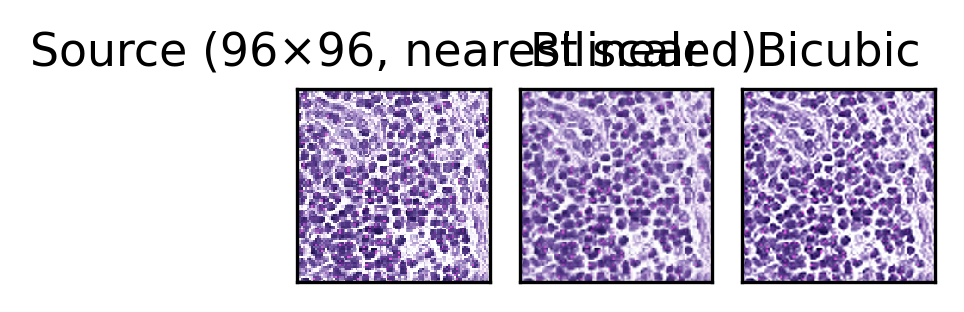

Saved composite: C:\GP_ECG\reports\figures\figure2_bicubic_vs_bilinear.png
Saved composite: C:\GP_ECG\reports\figures\figure2_bicubic_vs_bilinear.pdf
Panel tiles: C:\GP_ECG\reports\figures\figure2_bilinear_224px.png, etc.


In [19]:
# Save lossless per-panel tiles at native pixel size (224×224 for upsampled)
Image.fromarray(bilinear_224).save(FIG_DIR / "figure2_bilinear_224px.png")
Image.fromarray(bicubic_224).save(FIG_DIR / "figure2_bicubic_224px.png")
Image.fromarray(native_96).save(FIG_DIR / "figure2_source_96px.png")

# Composite figure: one row, native (nearest-upscaled for layout) | bilinear | bicubic
native_display = np.array(
    Image.fromarray(native_96).resize((TARGET_SIZE, TARGET_SIZE), Image.NEAREST)
)

panels = [
    (native_display, f"Source ({patch_96.shape[0]}×{patch_96.shape[1]}, nearest scaled)"),
    (bilinear_224, "Bilinear"),
    (bicubic_224, "Bicubic"),
]

ncols = len(panels)
fig_w_in = ncols * TARGET_SIZE / DPI
fig_h_in = TARGET_SIZE / DPI
fig, axes = plt.subplots(1, ncols, figsize=(fig_w_in, fig_h_in), dpi=DPI)
if ncols == 1:
    axes = [axes]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")

fig.subplots_adjust(wspace=0.04, left=0.01, right=0.99, top=0.88, bottom=0.02)
fig.savefig(FIG_PNG, dpi=DPI, bbox_inches="tight", pad_inches=0.02, facecolor="white")
fig.savefig(FIG_PDF, bbox_inches="tight", pad_inches=0.02, facecolor="white")
plt.show()

print("Saved composite:", FIG_PNG)
print("Saved composite:", FIG_PDF)
print(f"Panel tiles: {FIG_DIR / 'figure2_bilinear_224px.png'}, etc.")

### Optional: two-panel figure (bilinear vs bicubic only)

Use this version in the thesis if you do not want the source column.

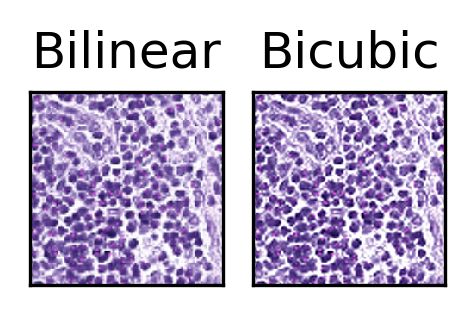

Saved: C:\GP_ECG\reports\figures\figure2_bicubic_vs_bilinear_pair.png


In [20]:
FIG_PNG_2 = FIG_DIR / "figure2_bicubic_vs_bilinear_pair.png"
FIG_PDF_2 = FIG_DIR / "figure2_bicubic_vs_bilinear_pair.pdf"

pair = [(bilinear_224, "Bilinear"), (bicubic_224, "Bicubic")]
fig, axes = plt.subplots(1, 2, figsize=(2 * TARGET_SIZE / DPI, TARGET_SIZE / DPI), dpi=DPI)
for ax, (img, title) in zip(axes, pair):
    ax.imshow(img, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=12)
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.88, bottom=0.02)
fig.savefig(FIG_PNG_2, dpi=DPI, bbox_inches="tight", pad_inches=0.02, facecolor="white")
fig.savefig(FIG_PDF_2, bbox_inches="tight", pad_inches=0.02, facecolor="white")
plt.show()
print("Saved:", FIG_PNG_2)